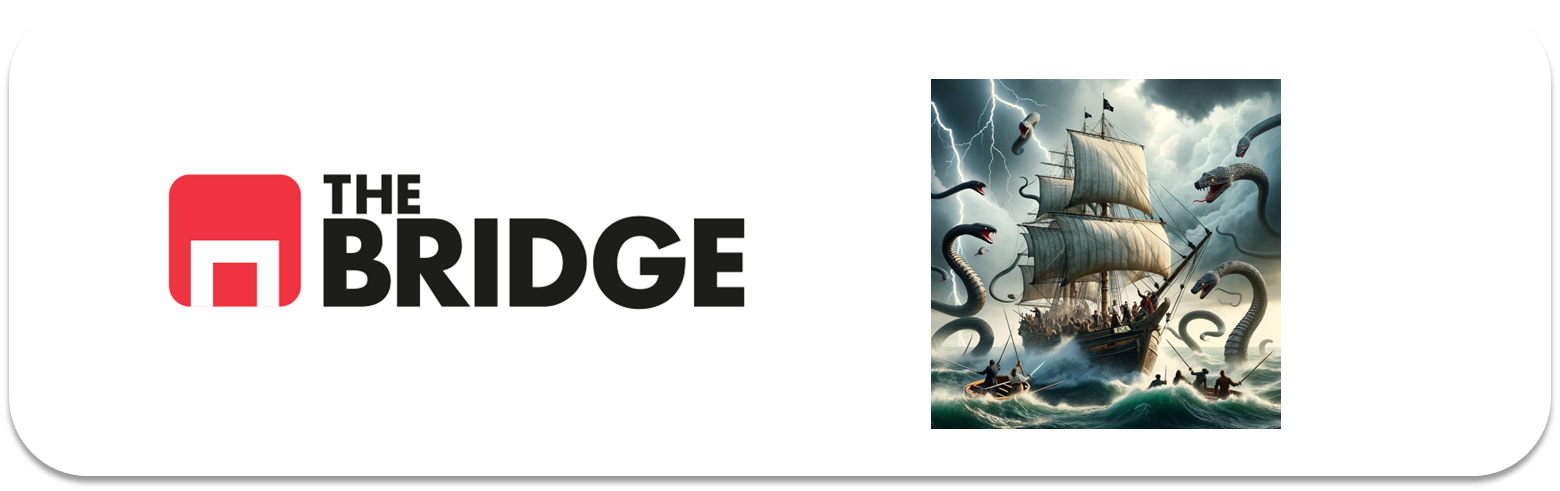

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from collections import Counter
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (VarianceThreshold, SelectKBest, f_classif,
                                       mutual_info_classif, SelectFromModel,
                                       RFE, SequentialFeatureSelector)
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

pd.options.mode.copy_on_write = True

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [43]:
df = pd.read_csv("data/credit_npo.csv")
print(df.shape)
df.info()

(12537, 11)
<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4),

In [44]:
# Fuera nulos sin contemplaciones
df.dropna(inplace=True)
print("Shape tras eliminar nulos:", df.shape)

target = "SeriousDlqin2yrs"

Shape tras eliminar nulos: (11816, 11)


In [45]:
# Split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {train_set.shape} | Test: {test_set.shape}")

Train: (9452, 11) | Test: (2364, 11)


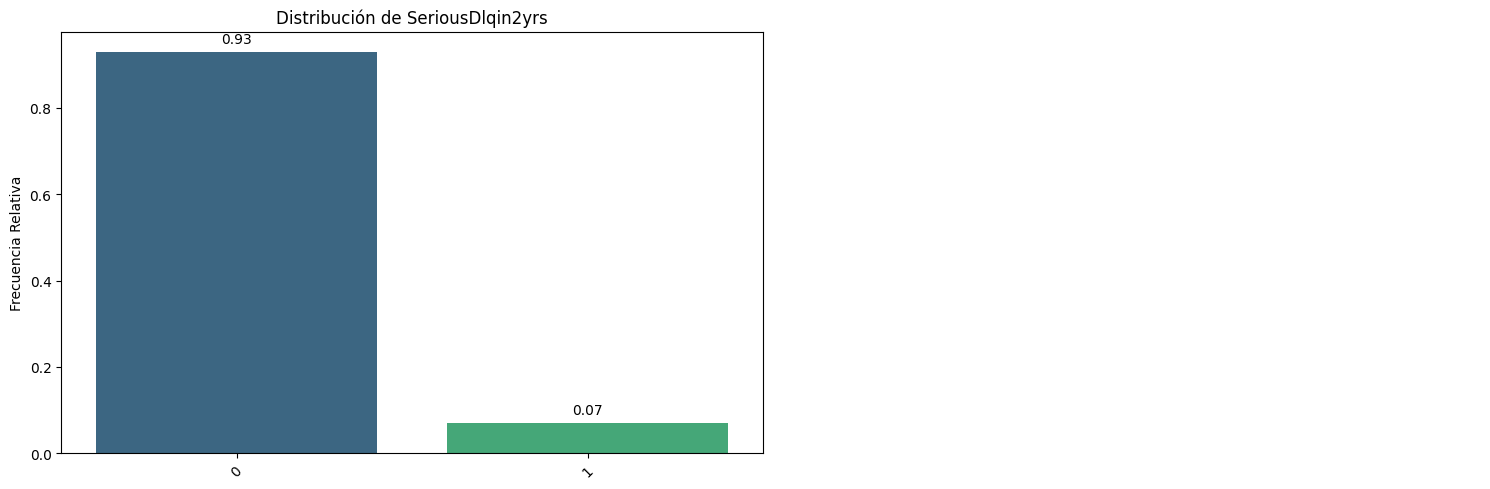

In [46]:
# Vistazo
bt.pinta_distribucion_categoricas(train_set, [target], True, True)
# Desbalanceado

In [47]:
#Describe + histogramas
print(train_set.describe().T)

                                       count         mean           std   min  \
SeriousDlqin2yrs                      9452.0     0.070144      0.255403   0.0   
RevolvingUtilizationOfUnsecuredLines  9452.0     0.335207      0.362233   0.0   
age                                   9452.0    51.491536     14.499298  21.0   
NumberOfTime30-59DaysPastDueNotWorse  9452.0     0.343314      2.930489   0.0   
DebtRatio                             9452.0     0.486047      2.505031   0.0   
MonthlyIncome                         9452.0  6868.428058  12580.543336   0.0   
NumberOfOpenCreditLinesAndLoans       9452.0     8.794647      5.139555   0.0   
NumberOfTimes90DaysLate               9452.0     0.180279      2.889984   0.0   
NumberRealEstateLoansOrLines          9452.0     1.064325      1.148156   0.0   
NumberOfTime60-89DaysPastDueNotWorse  9452.0     0.152772      2.870119   0.0   
NumberOfDependents                    9452.0     0.863415      1.158238   0.0   

                           

(10, 2)


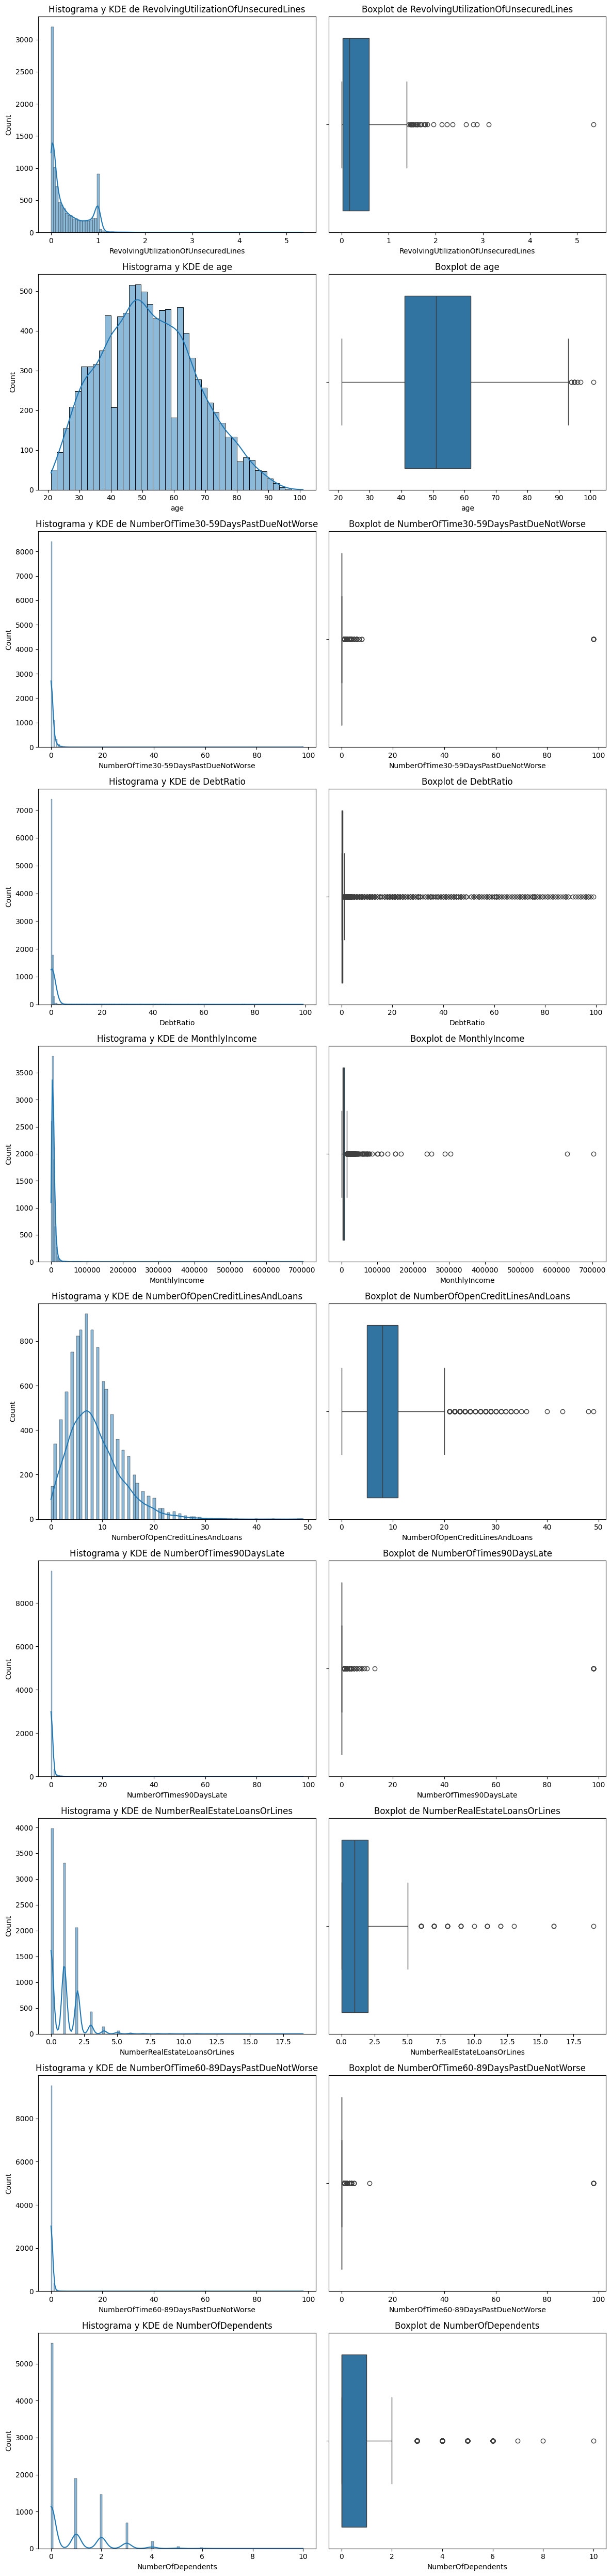

In [29]:
# Ver features
bt.plot_combined_graphs(train_set, [col for col in train_set.columns if col != target])

In [48]:
# Ver distribución de NumberOf
columnas_numberof = [col for col in df.columns if col.startswith("NumberOf")]
for col in columnas_numberof:
    dist = df[col].value_counts(normalize=True, dropna=False).sort_index()
    pct_ceros = dist.get(0, 0)
    print(f"\n{col} | valores_únicos = {df[col].nunique()} | %_ceros = {pct_ceros:.2%}")
    print((dist.head(10) * 100).round(2))


NumberOfTime30-59DaysPastDueNotWorse | valores_únicos = 10 | %_ceros = 83.09%
NumberOfTime30-59DaysPastDueNotWorse
0     83.09
1     11.46
2      3.36
3      1.07
4      0.54
5      0.19
6      0.17
7      0.01
8      0.02
98     0.08
Name: proportion, dtype: float64

NumberOfOpenCreditLinesAndLoans | valores_únicos = 43 | %_ceros = 0.95%
NumberOfOpenCreditLinesAndLoans
0    0.95
1    2.60
2    3.77
3    5.40
4    7.18
5    8.15
6    8.73
7    9.39
8    8.54
9    8.17
Name: proportion, dtype: float64

NumberOfTimes90DaysLate | valores_únicos = 13 | %_ceros = 94.41%
NumberOfTimes90DaysLate
0    94.41
1     3.33
2     1.20
3     0.46
4     0.26
5     0.12
6     0.05
7     0.03
8     0.03
9     0.01
Name: proportion, dtype: float64

NumberOfTime60-89DaysPastDueNotWorse | valores_únicos = 8 | %_ceros = 94.84%
NumberOfTime60-89DaysPastDueNotWorse
0     94.84
1      4.05
2      0.72
3      0.15
4      0.12
5      0.03
11     0.01
98     0.08
Name: proportion, dtype: float64

NumberOfDepende

In [49]:
# N30-59: tres niveles (0, 1, 2+) porque hay masa suficiente en 0, 1 y el resto
labels = [0, 1, 2]
train_set["N30-59"] = pd.cut(train_set["NumberOfTime30-59DaysPastDueNotWorse"],
                              bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)
test_set["N30-59"]  = pd.cut(test_set["NumberOfTime30-59DaysPastDueNotWorse"],
                              bins=[-1, 0, 1, np.inf], labels=labels, right=True).astype(int)

# N60-89 y N90: dos niveles (0 vs 1+), la masa en valores >1 es mínima
train_set["N60-89"] = (train_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)
test_set["N60-89"]  = (test_set["NumberOfTime60-89DaysPastDueNotWorse"] > 0).astype(int)

train_set["N90"] = (train_set["NumberOfTimes90DaysLate"] > 0).astype(int)
test_set["N90"]  = (test_set["NumberOfTimes90DaysLate"] > 0).astype(int)

# Listas de features por tipo
features_num = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
                "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans",
                "NumberOfDependents", "NumberRealEstateLoansOrLines"]

features_cat = ["N30-59", "N60-89", "N90"]

features = features_num + features_cat

print("Numéricas:", features_num)
print("Categóricas:", features_cat)

Numéricas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents', 'NumberRealEstateLoansOrLines']
Categóricas: ['N30-59', 'N60-89', 'N90']


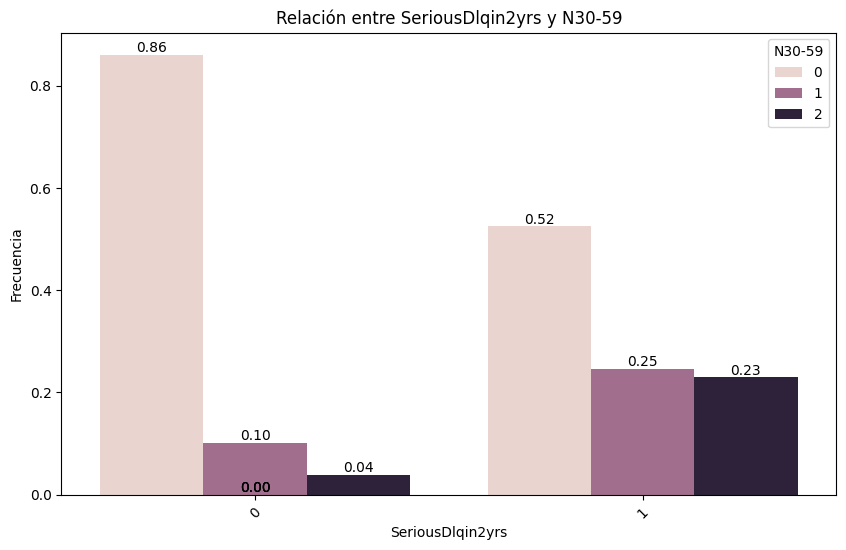

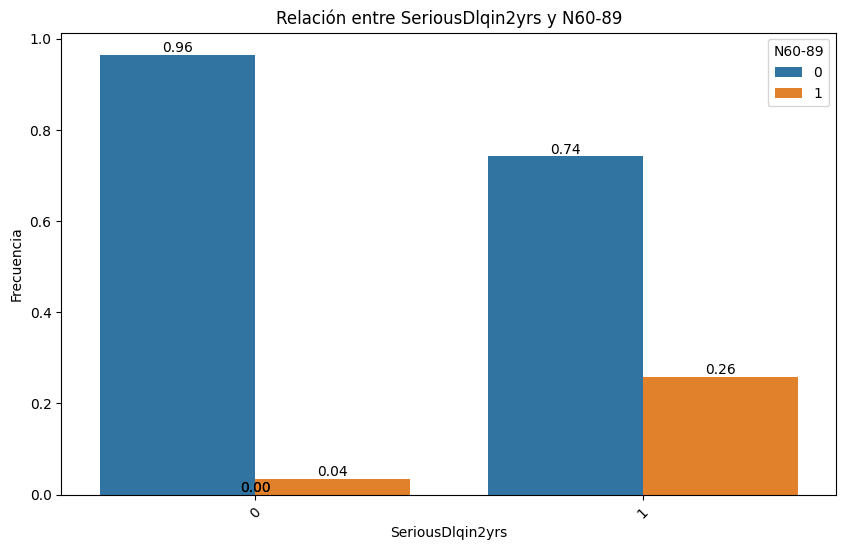

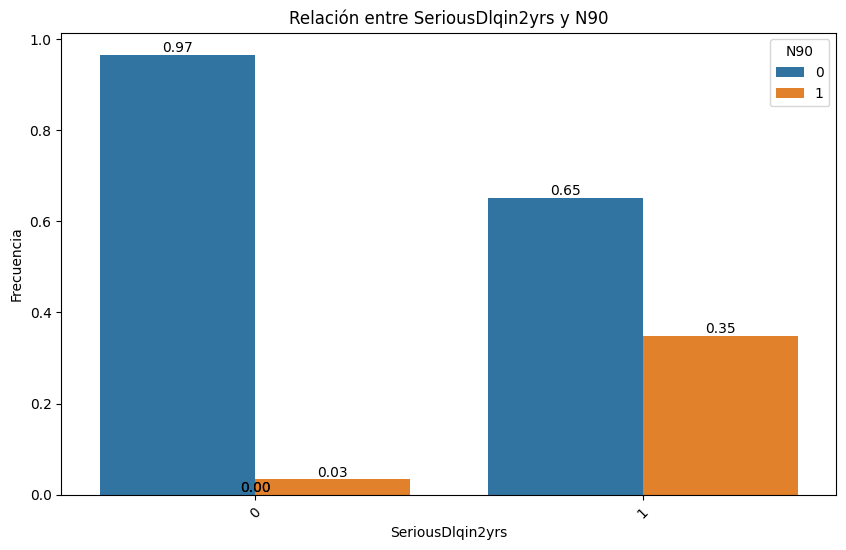

In [32]:
# Categorías contra el target: ¿discriminan bien?
for col in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, col, True, True)

features_visual = features_cat.copy()

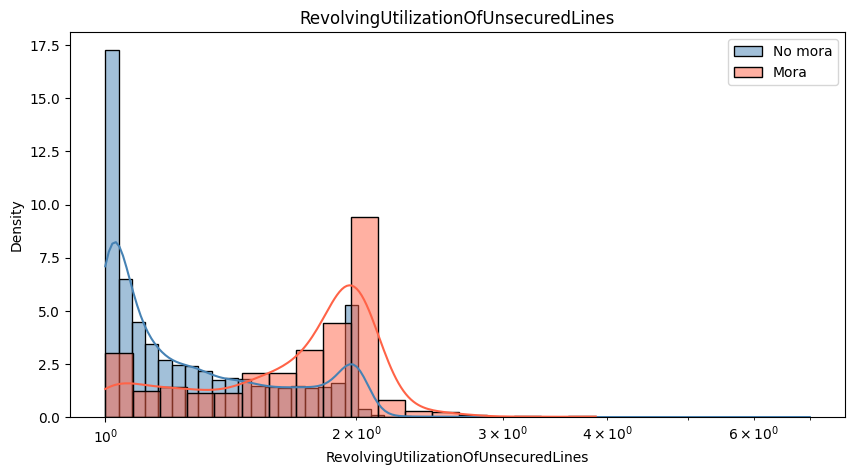

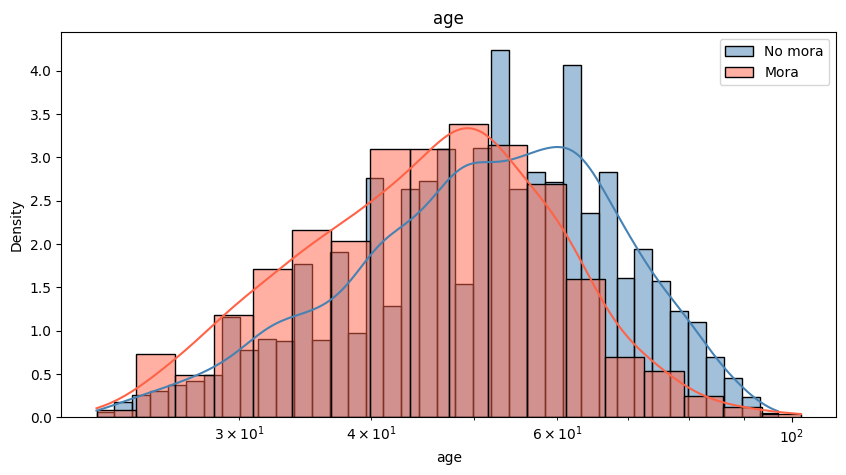

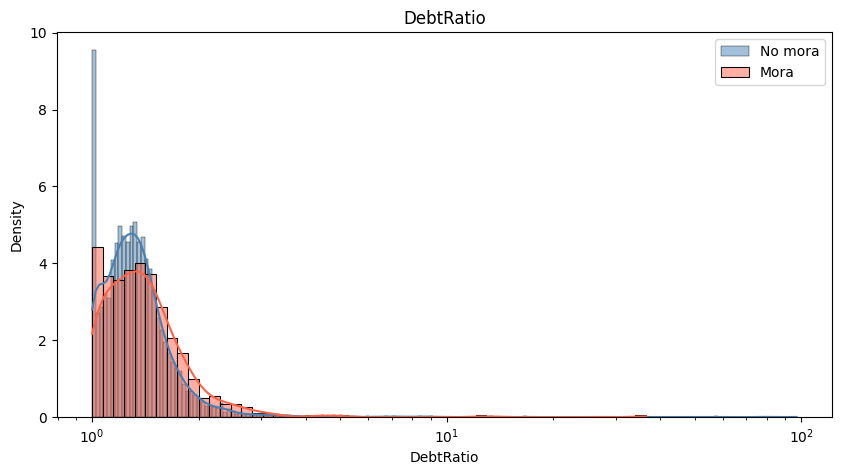

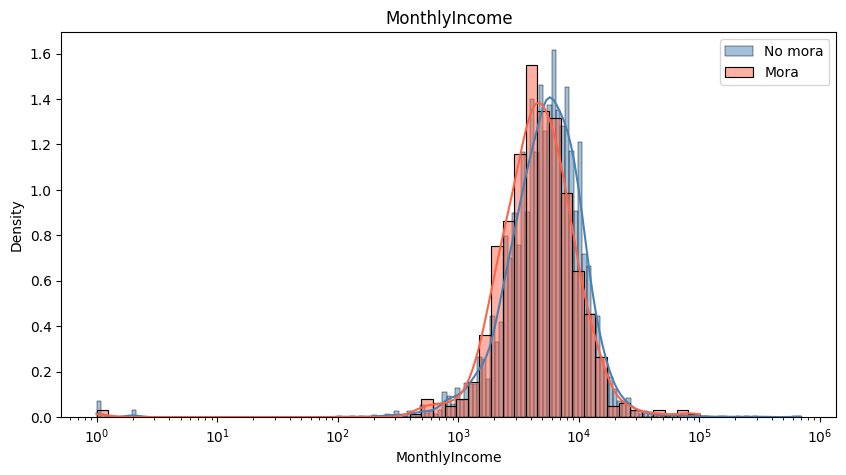

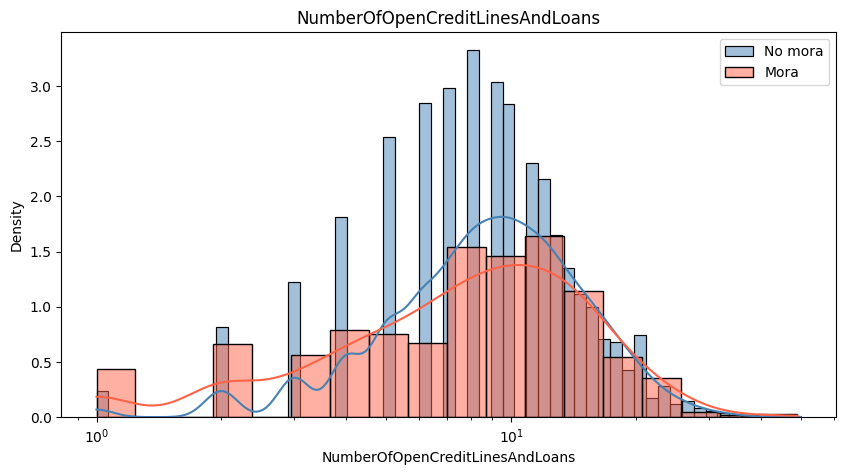

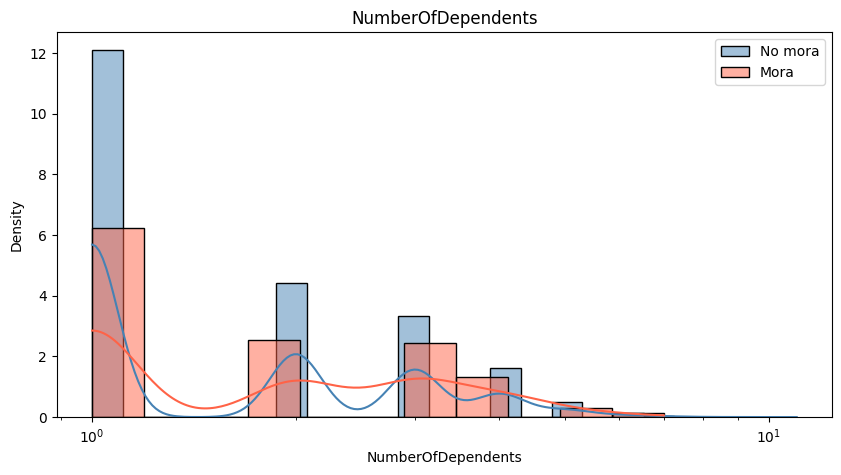

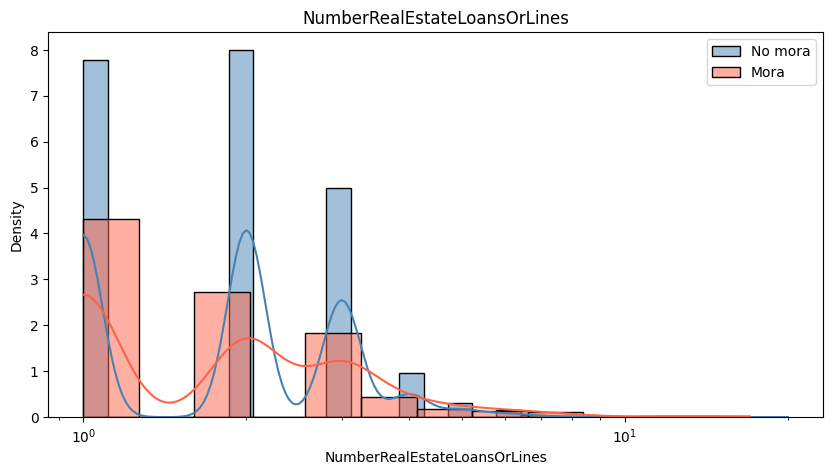

In [50]:
for col in features_num:
    plt.figure(figsize=(10, 5))
    sns.histplot(train_set.loc[train_set[target] == 0][col] + 1,
                 kde=True, stat="density", log_scale=10, label="No mora", color="steelblue")
    sns.histplot(train_set.loc[train_set[target] == 1][col] + 1,
                 kde=True, stat="density", log_scale=10, label="Mora", color="tomato")
    plt.title(col)
    plt.legend()
    plt.show()

In [51]:
features_visual.append("RevolvingUtilizationOfUnsecuredLines")
features_visual.append("age")

for col in ["MonthlyIncome", "DebtRatio"]:
    grupo_0 = train_set.loc[train_set[target] == 0][col]
    grupo_1 = train_set.loc[train_set[target] == 1][col]
    u_stat, p_valor = mannwhitneyu(grupo_0, grupo_1)
    print(f"{col} -> p-valor: {p_valor:.2e} | significativa: {p_valor < 0.05}")
    if p_valor < 0.05:
        features_visual.append(col)

print("\nSelección visual final:", features_visual)
# NumberOfDependents y NumberOfOpenCreditLines,sin diferencias claras

MonthlyIncome -> p-valor: 4.94e-09 | significativa: True
DebtRatio -> p-valor: 1.92e-05 | significativa: True

Selección visual final: ['N30-59', 'N60-89', 'N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'DebtRatio']


In [52]:
for umbral in np.arange(0, 1, 0.1):
    var_sel = VarianceThreshold(umbral)
    var_sel.fit(train_set[features_visual])
    print(f"Umbral {umbral:.1f} -> {list(var_sel.get_feature_names_out())}")

Umbral 0.0 -> ['N30-59', 'N60-89', 'N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.1 -> ['N30-59', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.2 -> ['N30-59', 'age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.3 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.4 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.5 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.6 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.7 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.8 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']
Umbral 0.9 -> ['age', 'DebtRatio', 'age', 'MonthlyIncome', 'DebtRatio']


In [36]:
X_train = train_set[features_num]
y_train = train_set[target]

selector_num = SelectKBest(f_classif, k=4)
selector_num.fit_transform(X_train, y_train)
features_anova = list(selector_num.get_feature_names_out())
print("ANOVA top 4:", features_anova)

selector_cat = SelectKBest(mutual_info_classif, k=3)
selector_cat.fit_transform(X_train_cat, y_train)
features_mi = list(selector_cat.get_feature_names_out())
print("MI categóricas:", features_mi)
print("Scores MI:", mutual_info_classif(X_train_cat, y_train, random_state=42))

features_filter = features_anova + features_mi
print("\nSelección por filtrado:", features_filter)

ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [37]:
X_train = train_set[features]
y_train = train_set[target]

rf_sel = RandomForestClassifier(random_state=42, class_weight="balanced")
selector_modelo = SelectFromModel(estimator=rf_sel, threshold="median")
selector_modelo.fit(X_train, y_train)
features_modelo = list(selector_modelo.get_feature_names_out())
print("SelectFromModel:", features_modelo)

# Visualizamos importancias para entender la decisión
rf_check = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_check.fit(X_train, y_train)
df_importance = pd.DataFrame(rf_check.feature_importances_,
                              columns=["importance"],
                              index=features).sort_values("importance", ascending=False)
print(df_importance)

SelectFromModel: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'N90']
                                      importance
RevolvingUtilizationOfUnsecuredLines    0.274892
age                                     0.125247
MonthlyIncome                           0.121996
DebtRatio                               0.121442
N90                                     0.087743
NumberOfOpenCreditLinesAndLoans         0.080501
N30-59                                  0.075718
NumberRealEstateLoansOrLines            0.038084
N60-89                                  0.037274
NumberOfDependents                      0.037103


In [38]:
# RFE: elimina features de una en una según importancia del modelo
rf_rfe = RandomForestClassifier(random_state=42, class_weight="balanced")
rfe = RFE(estimator=rf_rfe, n_features_to_select=6, step=1)
rfe.fit(train_set[features], y_train)
features_RFE = list(rfe.get_feature_names_out())
print("RFE:", features_RFE)

RFE: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'N90']


In [39]:
rf_sfs = RandomForestClassifier(class_weight="balanced", random_state=42)
sfs = SequentialFeatureSelector(rf_sfs,
                                 n_features_to_select=5,
                                 cv=4,
                                 scoring="balanced_accuracy",
                                 n_jobs=-1)
sfs.fit(train_set[features], y_train)
features_SFS = list(sfs.get_feature_names_out())
print("SFS:", features_SFS)

SFS: ['NumberOfDependents', 'NumberRealEstateLoansOrLines', 'N30-59', 'N60-89', 'N90']


In [40]:
lista_total = features_visual + features_filter + features_modelo + features_RFE + features_SFS
votaciones = Counter(lista_total)

escrutinio = pd.DataFrame(votaciones.values(),
                           columns=["Votos"],
                           index=votaciones.keys()).sort_values("Votos", ascending=False)
print(escrutinio)

features_hard_voting = escrutinio["Votos"].nlargest(6).index.to_list()
print("\nFeatures ganadoras por voting:", features_hard_voting)


                                      Votos
N90                                       5
RevolvingUtilizationOfUnsecuredLines      4
age                                       4
N30-59                                    3
N60-89                                    3
DebtRatio                                 3
NumberOfOpenCreditLinesAndLoans           2
NumberOfDependents                        2
MonthlyIncome                             2
NumberRealEstateLoansOrLines              1

Features ganadoras por voting: ['N90', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'N30-59', 'N60-89', 'DebtRatio']


In [41]:
#La gran comparativa
X_train = train_set[features]
y_train = train_set[target]

ratio_desbalanceo = len(train_set[train_set[target] == 0]) / len(train_set[train_set[target] == 1])

rf_clf  = RandomForestClassifier(class_weight="balanced", random_state=42)
xg_clf  = XGBClassifier(random_state=42, scale_pos_weight=ratio_desbalanceo)
lgb_clf = LGBMClassifier(class_weight="balanced", random_state=42, verbose=-100, n_jobs=-1)

modelos      = [rf_clf, xg_clf, lgb_clf]
model_names  = ["Random Forest", "XGBoost", "LightGBM"]
nombres_sel  = ["visual", "filter", "modelo", "rfe", "sfs", "voting"]
listas_sel   = [features_visual, features_filter, features_modelo,
                features_RFE, features_SFS, features_hard_voting]

resultados = []
for nombre, lista in zip(nombres_sel, listas_sel):
    for model_name, modelo in zip(model_names, modelos):
        score = np.mean(cross_val_score(modelo, train_set[lista], y_train,
                                         cv=5, scoring="balanced_accuracy"))
        fila = {"seleccion": nombre, "modelo": model_name, "balanced_accuracy": round(score, 4)}
        print(fila)
        resultados.append(fila)

df_resultados = pd.DataFrame(resultados).sort_values("balanced_accuracy", ascending=False)
df_resultados

{'seleccion': 'visual', 'modelo': 'Random Forest', 'balanced_accuracy': np.float64(0.5618)}
{'seleccion': 'visual', 'modelo': 'XGBoost', 'balanced_accuracy': np.float64(0.6431)}
{'seleccion': 'visual', 'modelo': 'LightGBM', 'balanced_accuracy': np.float64(0.7328)}
{'seleccion': 'filter', 'modelo': 'Random Forest', 'balanced_accuracy': np.float64(0.5756)}
{'seleccion': 'filter', 'modelo': 'XGBoost', 'balanced_accuracy': np.float64(0.6636)}
{'seleccion': 'filter', 'modelo': 'LightGBM', 'balanced_accuracy': np.float64(0.7581)}
{'seleccion': 'modelo', 'modelo': 'Random Forest', 'balanced_accuracy': np.float64(0.5529)}
{'seleccion': 'modelo', 'modelo': 'XGBoost', 'balanced_accuracy': np.float64(0.6277)}
{'seleccion': 'modelo', 'modelo': 'LightGBM', 'balanced_accuracy': np.float64(0.7092)}
{'seleccion': 'rfe', 'modelo': 'Random Forest', 'balanced_accuracy': np.float64(0.5602)}
{'seleccion': 'rfe', 'modelo': 'XGBoost', 'balanced_accuracy': np.float64(0.6342)}
{'seleccion': 'rfe', 'modelo': 'L

,seleccion,modelo,balanced_accuracy
5,filter,LightGBM,0.7581
14,sfs,LightGBM,0.7331
17,voting,LightGBM,0.7328
2,visual,LightGBM,0.7328
13,sfs,XGBoost,0.7239
11,rfe,LightGBM,0.7163
8,modelo,LightGBM,0.7092
12,sfs,Random Forest,0.7023
4,filter,XGBoost,0.6636
16,voting,XGBoost,0.6465


In [ ]:
# Ver ganador
# Café, café, café...
param_grid = {
    "n_estimators":    [100, 200],
    "learning_rate":   [0.1, 0.5, 1],
    "max_depth":       [5, 10, 15],
    "min_data_in_leaf":[1, 10, 20, 100],
    "class_weight":    ["balanced", None]
}

lgb_final = LGBMClassifier(verbose=-100)
grid = GridSearchCV(lgb_final, param_grid=param_grid,
                    cv=5, scoring="balanced_accuracy", n_jobs=-1)
grid.fit(train_set[features_SFS], y_train)  # <- cambia si gana otra selección

print("Mejores params:", grid.best_params_)
print("Mejor score CV:", round(grid.best_score_, 4))

Mejores params: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': 5, 'min_data_in_leaf': 100, 'n_estimators': 200}
Mejor score CV: 0.7467


In [ ]:
#Evaluación del modelo optimizado contra test
X_test = test_set[features_SFS]
y_test = test_set[target]

y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2197
           1       0.22      0.59      0.32       167

    accuracy                           0.82      2364
   macro avg       0.59      0.71      0.61      2364
weighted avg       0.91      0.82      0.86      2364



**Conclusión final:**
El modelo LightGBM con la selección SFS obtiene un balanced_accuracy de 0.71 en test
(recall medio entre clase 0 y clase 1).

El recall de la clase 1 (morosos) es 0.59 — detecta 6 de cada 10 morosos reales,
que es el objetivo principal en credit scoring: mejor un falso positivo que dejar
pasar un moroso.

La precisión de la clase 1 es baja (0.22), es decir hay bastantes falsos positivos,
pero es el trade-off habitual con datasets tan desbalanceados (93% vs 7%).

El modelo es útil como primera criba pero necesitaría más datos de la clase minoritaria
o técnicas de oversampling (SMOTE) para mejorar la precisión en morosos.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.